# **Churn Prediction**

| Atributo | Descrição |
|---|---|
| `customerID` | Identificador único do cliente. |
| `gender` | Gênero do cliente (Masculino ou Feminino). |
| `SeniorCitizen` | Indica se o cliente é idoso (1 = Sim, 0 = Não). |
| `Partner` | Indica se o cliente possui parceiro(a) (Sim ou Não). |
| `Dependents` | Indica se o cliente possui dependentes (Sim ou Não). |
| `tenure` | Número de meses em que o cliente permaneceu na empresa. |
| `PhoneService` | Indica se o cliente possui serviço de telefonia (Sim ou Não). |
| `MultipleLines` | Indica se o cliente possui múltiplas linhas telefônicas (Sim, Não ou Sem serviço telefônico). |
| `InternetService` | Tipo de serviço de internet contratado pelo cliente (DSL, Fibra óptica ou Sem serviço de internet). |
| `OnlineSecurity` | Indica se o cliente possui serviço de segurança online (Sim, Não ou Sem serviço de internet). |
| `OnlineBackup` | Indica se o cliente possui serviço de backup online (Sim, Não ou Sem serviço de internet). |
| `DeviceProtection` | Indica se o cliente possui proteção para dispositivos (Sim, Não ou Sem serviço de internet). |
| `TechSupport` | Indica se o cliente possui suporte técnico (Sim, Não ou Sem serviço de internet). |
| `StreamingTV` | Indica se o cliente possui serviço de streaming de TV (Sim, Não ou Sem serviço de internet). |
| `StreamingMovies` | Indica se o cliente possui serviço de streaming de filmes (Sim, Não ou Sem serviço de internet). |
| `Contract` | Tipo de contrato do cliente (Mensal, Um ano ou Dois anos). |
| `PaperlessBilling` | Indica se o cliente utiliza faturamento sem papel (Sim ou Não). |
| `PaymentMethod` | Método de pagamento utilizado pelo cliente (Cheque eletrônico, Cheque enviado pelo correio, Transferência bancária automática ou Cartão de crédito automático). |
| `MonthlyCharges` | Valor cobrado mensalmente do cliente. |
| `TotalCharges` | Valor total cobrado do cliente durante o período de relacionamento com a empresa. |
| `Churn` | Indica se o cliente cancelou o serviço (Sim ou Não). |

## 1. Importando bibliotecas

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import pickle

## 2. Carregando os dados e executando análises iniciais

In [4]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [ ]:
df.isnull().sum() # não há valores nulos na base

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
df[df.duplicated()] # não há registros duplicados na base

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [ ]:
# removendo customerId, pois a coluna não é util para a modelagem
df.drop(columns=['customerID'], inplace=True)

In [11]:
df.nunique()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [12]:
numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]

In [ ]:
# analisando a coluna TotalCharges, que veio como str, mas era para ser float
df[df['TotalCharges'] == ' '] # 11 registros com valores ausentes, todos eles com tenure 0, ou seja, clientes que acabaram de ingressar no serviço e ainda não foram cobrados o valor.

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [37]:
df['TotalCharges'] = df['TotalCharges'].replace(" ", 0).astype(float)

## 3. EDA

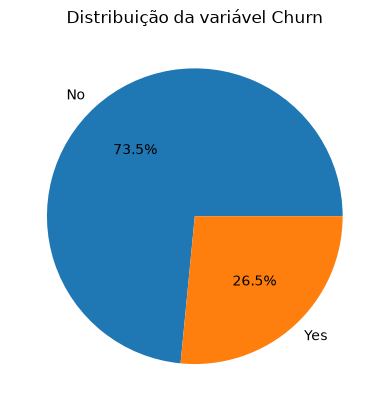

In [ ]:
# verificando a distribuição de churn
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Distribuição da variável Churn'); # DATASET DESBALANCEADO !!

In [38]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


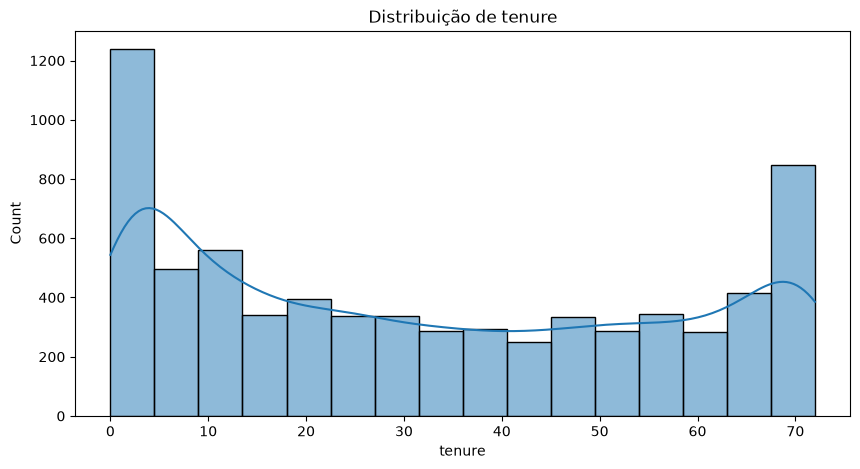

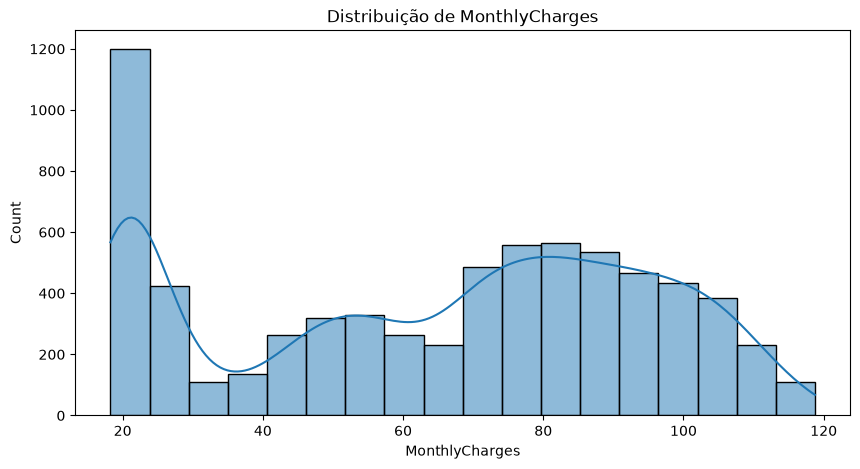

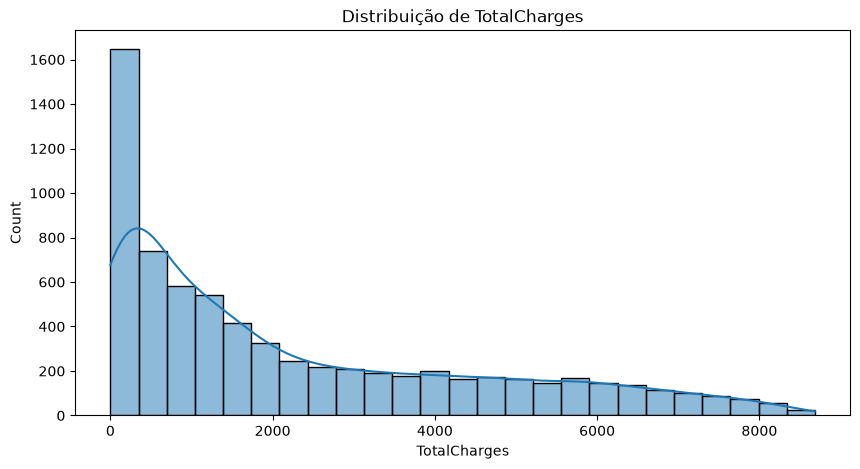

In [42]:
def hist_plot(df:pd.DataFrame, column:str):
    plt.figure(figsize=(10,5))
    sns.histplot(data=df, x=column, kde=True)
    plt.title(f"Distribuição de {column}")
    plt.xlabel(column)
    plt.show()

hist_plot(df, 'tenure')
hist_plot(df, 'MonthlyCharges')
hist_plot(df, 'TotalCharges')

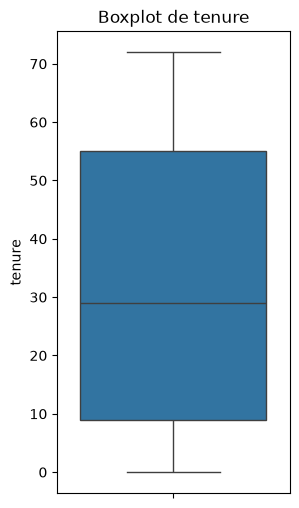

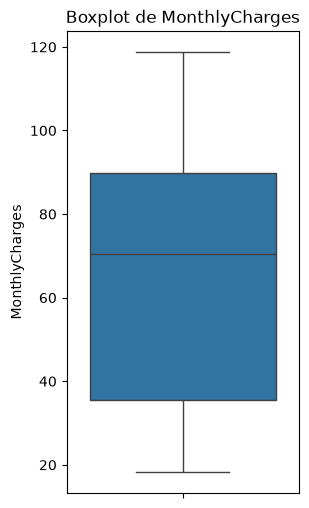

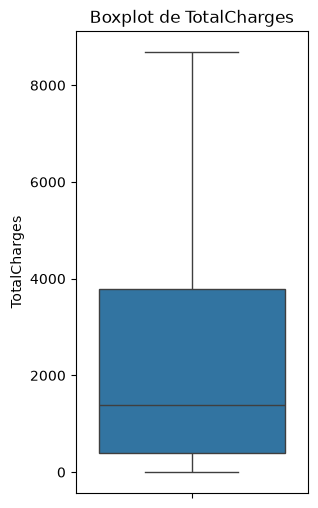

In [ ]:
def box_plot(df:pd.DataFrame, column:str):
    plt.figure(figsize=(3,6))
    sns.boxplot(data=df, y=column)
    plt.title(f"Boxplot de {column}")
    plt.show()

# sem presença de outliers
box_plot(df, 'tenure')
box_plot(df, 'MonthlyCharges')
box_plot(df, 'TotalCharges')

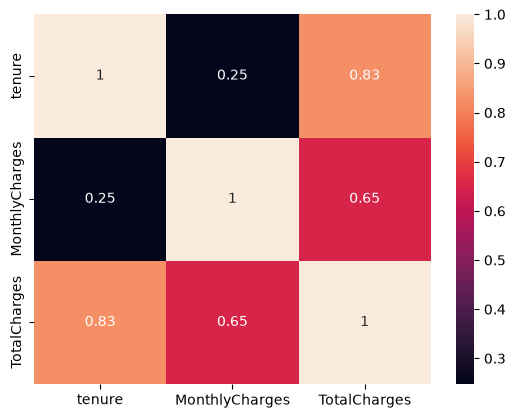

In [49]:
corr = df[numerical_features].corr(numeric_only=True)
sns.heatmap(corr, annot=True); # multicolinearidade entre Tenure e TotalCharges & MonthlyCharges e TotalCharges, pois TotalCharges = Tenure * MonthlyCharges.

In [51]:
categorical_columns = df.select_dtypes(str).columns.to_list() + ['SeniorCitizen']
categorical_columns

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn',
 'SeniorCitizen']

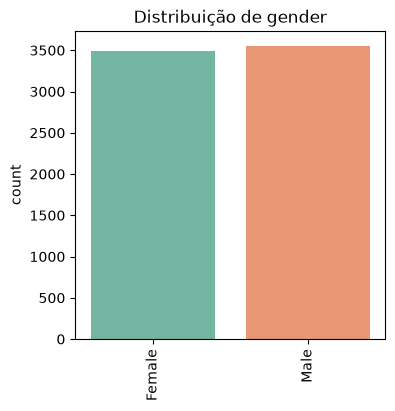

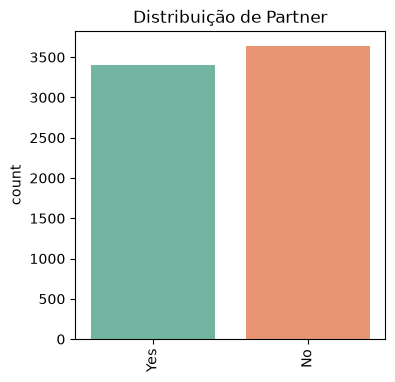

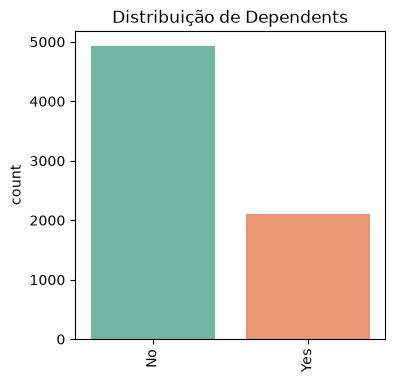

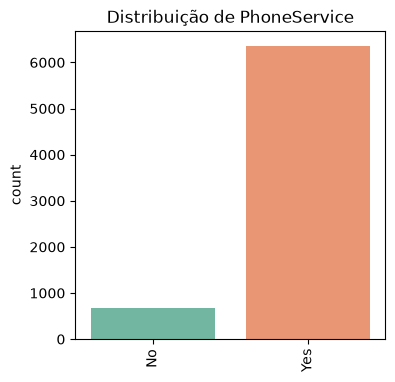

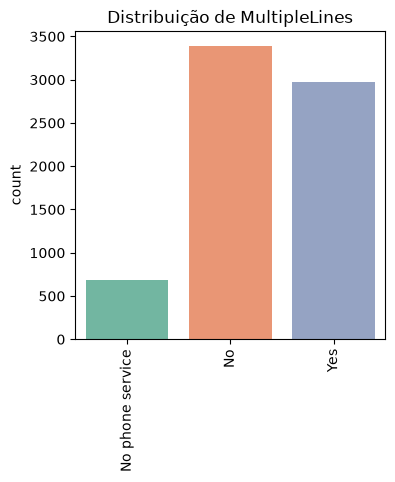

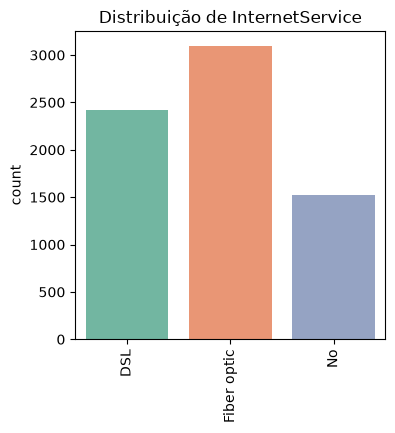

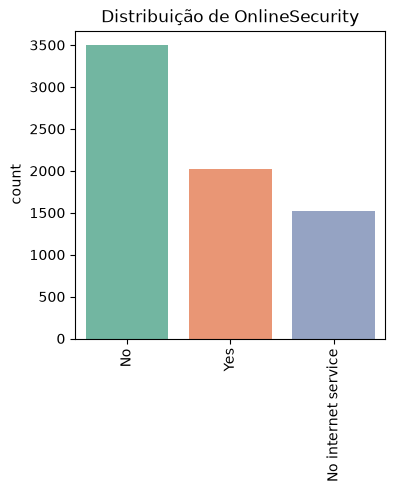

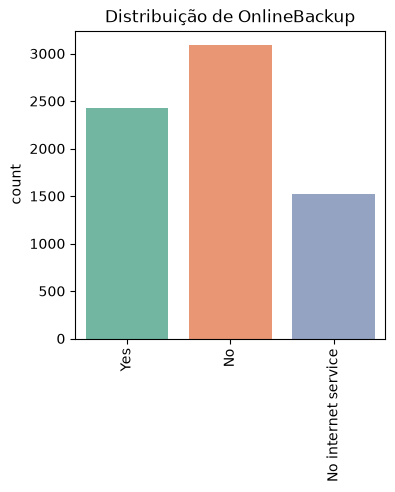

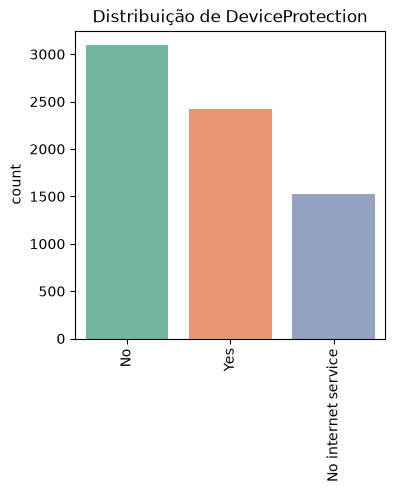

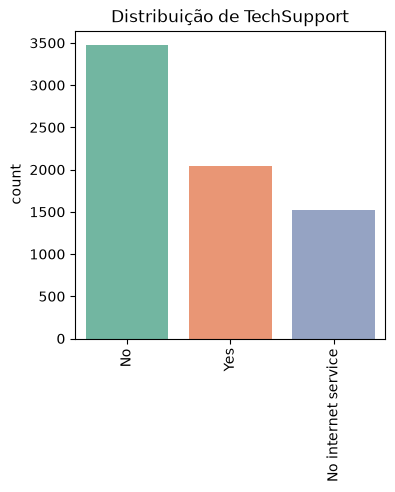

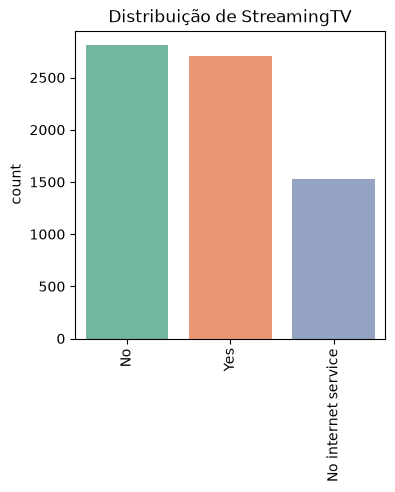

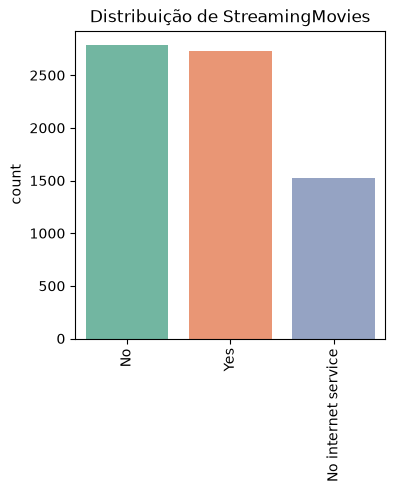

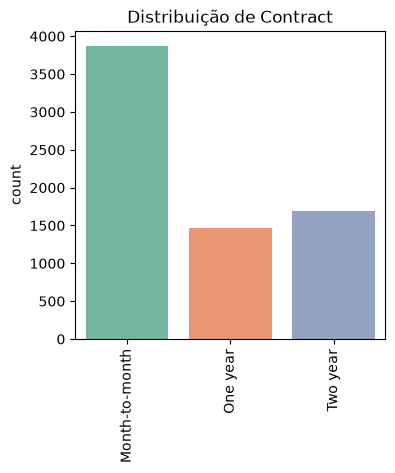

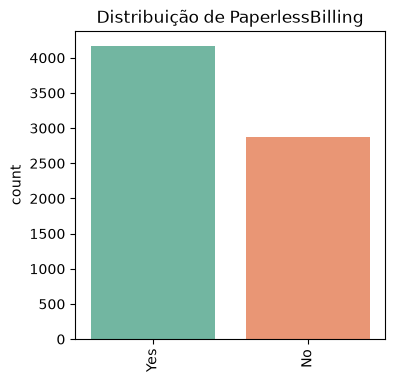

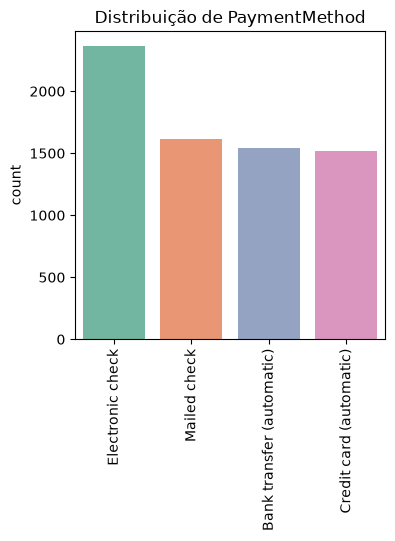

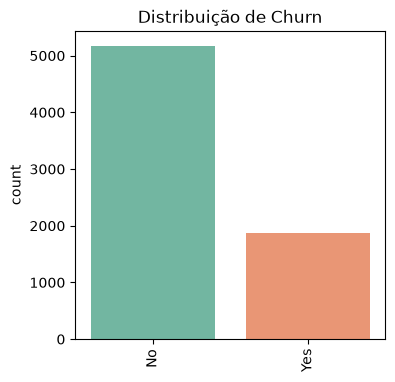

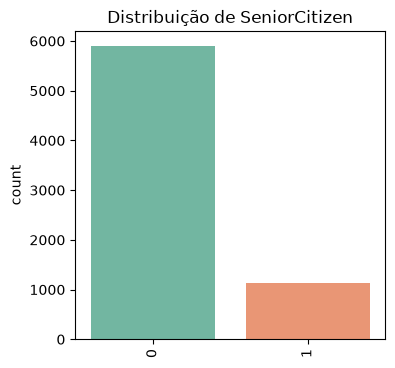

In [60]:
for col in categorical_columns:
    plt.figure(figsize=(4,4))
    sns.countplot(df, x=col, hue=col, palette='Set2', legend=False)
    plt.title(f"Distribuição de {col}")
    plt.xlabel("")
    plt.xticks(rotation=90)
    plt.show()

## 4. Pré-processamento

In [61]:
# label encoding da coluna Churn
df["Churn"] = df["Churn"].replace({"Yes": 1, "No": 0})

In [62]:
categorical_columns = df.select_dtypes(str).columns.to_list()
categorical_columns

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [63]:
encoders = {}

# codificando as variáveis para transformá-las em numéricas
for col in categorical_columns:
    label_encoder = LabelEncoder()
    df[col] = label_encoder.fit_transform(df[col])
    encoders[col] = label_encoder

In [64]:
with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

In [ ]:
df.head() # agora todas as colunas são numéricas

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [74]:
X = df.drop(columns=['Churn'])
y = df['Churn'].astype(int)

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=42
)

In [76]:
X_train.shape, X_test.shape

((5634, 19), (1409, 19))

In [77]:
y_train.dtype, y_train.unique()

(dtype('int64'), array([0, 1]))

In [78]:
# Oversampling
smote = SMOTE(random_state=42)
X_train_oversampling, y_train_oversampling = smote.fit_resample(X_train, y_train)

In [82]:
y_train_oversampling.value_counts()

Churn
0    4138
1    4138
Name: count, dtype: int64

In [ ]:
# Undersampling
random_under_sampler = RandomUnderSampler()
X_train_undersampling, y_train_undersampling = random_under_sampler.fit_resample(X_train, y_train)

In [83]:
y_train_undersampling.value_counts()

Churn
0    1496
1    1496
Name: count, dtype: int64

## 5. Treinamento e avaliação dos modelos

### Oversampling

In [84]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGB': XGBClassifier(random_state=42)
}

In [88]:
cv_scores = {}

for model_name, model in models.items():
    scores = cross_val_score(model, X_train_oversampling, y_train_oversampling, cv=5, scoring='accuracy')
    cv_scores[model_name] = scores
    print(f"{model_name}, acurácia: {scores.mean():.2f} +- {scores.std():.2f}.")

Decision Tree, acurácia: 0.78 +- 0.07.
Random Forest, acurácia: 0.84 +- 0.07.
XGB, acurácia: 0.83 +- 0.08.


Random Forest obteve melhor acurácia com parâmetros default.

In [100]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train_oversampling, y_train_oversampling)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [101]:
y_pred = rfc.predict(X_test)

In [102]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1036
           1       0.58      0.57      0.58       373

    accuracy                           0.78      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.78      0.78      0.78      1409



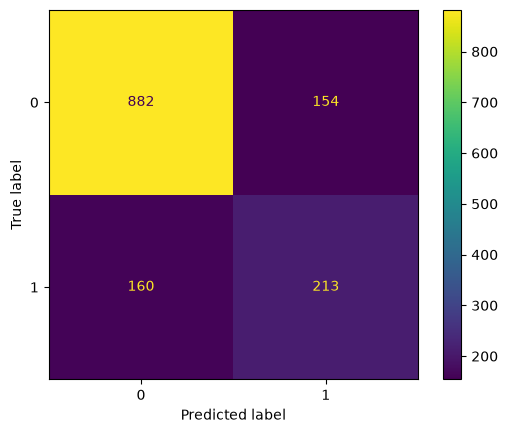

In [103]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot();

In [104]:
# salvando o modelo
with open('customer_churn_model.pkl', 'wb') as f:
    pickle.dump(rfc, f)

### Undersampling

In [94]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGB': XGBClassifier(random_state=42)
}

In [95]:
cv_scores = {}

for model_name, model in models.items():
    scores = cross_val_score(model, X_train_undersampling, y_train_undersampling, cv=5, scoring='accuracy')
    cv_scores[model_name] = scores
    print(f"{model_name}, acurácia: {scores.mean():.2f} +- {scores.std():.2f}.")

Decision Tree, acurácia: 0.67 +- 0.01.
Random Forest, acurácia: 0.74 +- 0.01.
XGB, acurácia: 0.72 +- 0.02.


Random forest novamente obteve melhores resultados, mas os do Oversampling foram melhores

In [96]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train_undersampling, y_train_undersampling)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [97]:
y_pred = rfc.predict(X_test)

In [98]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1036
           1       0.51      0.77      0.62       373

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.75      0.76      1409



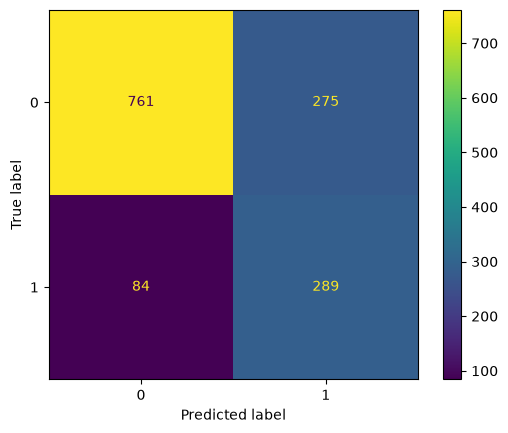

In [99]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot();